In [1]:
import numpy as np
import torch
from tuned_lens.nn.lenses import TunedLens, LogitLens
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt
from tuned_lens.plotting import PredictionTrajectory
from tqdm import tqdm

from joblib import Parallel, delayed
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from dadapy import data
from dadapy.data import Data
import scipy

from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

import matplotlib.colors as mcolors
hex6 = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']
colors6=[mcolors.to_rgb(i) for i in hex6]
from scipy.spatial.distance import pdist, squareform

In [2]:
model = AutoModelForCausalLM.from_pretrained('gpt2-large', device_map="auto")
device = torch.device('cuda')
tokenizer = AutoTokenizer.from_pretrained('gpt2-large')
tuned_lens = TunedLens.from_model_and_pretrained(model)
tuned_lens = tuned_lens.to(device)

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/users/viswanat/.local/lib/python3.10/site-packages/tuned_lens/nn/lenses.py:277: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no long

In [3]:
ds = load_dataset("NeelNanda/pile-10k")['train']
filtered_indices = np.load('filtered_indices.npy')
subset_indices = np.load('subset_indices.npy')

In [8]:
def shuffle_tokens(ids, shuffle_index):
    N, K = ids.shape[-1], 4**shuffle_index
    block_size = N//K
    permutation = np.random.permutation(K)
    new_ids = ids.reshape((1, K, block_size))
    new_ids = new_ids[0, permutation, :]
    new_ids = new_ids.reshape(1, N)
    return new_ids
    
def get_logits(test_sequence, max_length = 256, lens = tuned_lens, shuffle_indx = 0):
    input_ids = tokenizer.encode(test_sequence.strip(), add_special_tokens = False, \
                         return_tensors = "pt", max_length = max_length, truncation = True)
    # if shuffled:
    input_ids = shuffle_tokens(input_ids, shuffle_indx).to(device)
    all_logits = []
    all_probs = []
    with torch.no_grad():
        # input_ids_th = torch.tensor(input_ids.clone().detach(), dtype=torch.int64, device=model.device)
        input_ids_th = input_ids.clone().detach().to(model.device)
        outputs = model(input_ids_th, output_hidden_states=True)
        stream = list(outputs.hidden_states)
        # Create the stream of log probabilities from the lens
        for i, h in enumerate(stream[:-1]):
            logits = lens.forward(h, i).squeeze()
            probs = torch.nn.functional.softmax(logits, dim = -1)
            all_logits.append(logits)
            all_probs.append(probs)
        all_logits.append(outputs.logits.squeeze())
        all_probs.append(torch.nn.functional.softmax(outputs.logits.squeeze(), dim = -1))
        return all_logits, all_probs

def calculate_moments(all_logits, all_probs):
    all_probs_com = []
    all_logits_com = []
    n_layers = len(all_logits)
    all_entropies = []
    with torch.no_grad():
        for idx in range(n_layers):
            logits, probs = all_logits[idx], all_probs[idx]
            probs_com = torch.mean(probs, axis = -2).squeeze()
            all_probs_com.append(probs_com)
            logits_com = torch.log(probs_com)
            logits_com_mean = torch.sum(probs_com * logits_com)
            all_logits_com.append(logits_com - logits_com_mean)
            all_entropies.append(-(probs*torch.log(probs)).sum(axis = -1).cpu().detach().numpy())
        
        all_probs_com = torch.stack(all_probs_com, axis = 0)
        all_logits_com = torch.stack(all_logits_com, axis = 0)
    all_cumulants = []
    with torch.no_grad():
        for idx in range(n_layers):
            delta_logits = all_logits_com[idx] - all_logits[idx]
            centered_delta_logits = delta_logits - (all_probs[idx] * delta_logits).sum(axis = -1, keepdims = True)
            m1 = (all_probs[idx] * (centered_delta_logits)).sum(axis = -1)
            m2 = (all_probs[idx] * (centered_delta_logits**2)).sum(axis = -1)
            m3 = (all_probs[idx] * (centered_delta_logits**3)).sum(axis = -1)
            m4 = (all_probs[idx] * (centered_delta_logits**4)).sum(axis = -1)
            m5 = (all_probs[idx] * (centered_delta_logits**5)).sum(axis = -1)
            m6 = (all_probs[idx] * (centered_delta_logits**6)).sum(axis = -1)
            m7 = (all_probs[idx] * (centered_delta_logits**7)).sum(axis = -1)
            m8 = (all_probs[idx] * (centered_delta_logits**8)).sum(axis = -1)
            
            # print(variance.shape)
            k2 = torch.mean(m2)
            k3 = torch.mean(m3)
            k4 = torch.mean(m4 - 3*m2**2)
            k5 = torch.mean(m5 - 10*m2*m3)
            k6 = torch.mean(m6 - 15*m2*m4 - 10 * m3 **2 + 30 * m2**3)
            k7 = torch.mean(m7 - 21 * m2 * m5 - 35 * m3 * m4 + 210* (m2**2) * m3)
            k8 = torch.mean(m8 - 28 * m2 * m6 - 56 * m3 * m5 + 420 * m2**2 * m4 - 35 * m4 * m4 + 560 * m2 * m3 * m3 - 630 * m2**4)
    #         cumulant5 = (moments[5] - 10 * moments[3]*moments[2]).mean()
            
            all_cumulants.append(torch.stack([k2, k3, k4, k5, k6, k7, k8]))
    return all_cumulants, all_probs_com

In [10]:
def plot_stats(test_indx, ax):
    prompt_indx = filtered_indices[test_indx]
    topic = ds['meta'][prompt_indx]
    test_sequence = ds['text'][prompt_indx].strip()
    all_logits, all_probs = get_logits(test_sequence, max_length = max_length)
    all_cumulants, all_probs_com = calculate_moments(all_logits, all_probs)
    entropy = -torch.sum(all_probs_com * torch.log(all_probs_com + 1e-12), axis = -1).cpu().detach().numpy()
    all_cumulants_np = torch.stack(all_cumulants).cpu().detach().numpy()/np.array([2, 6, 24, 120, 720, 5040, 40320])
    for idx in range(7):
        plt.plot(all_cumulants_np.T[idx], marker = '.', label = idx + 2)
    # plt.plot(np.array(all_entropies).mean(axis = -1), marker = '.', c = 'black', linestyle = '-')
    ax.axvline(16, c = 'red', linestyle = 'dotted')
    ax.set_title(topic)
    ax.grid(True)
    ax.legend()
    

In [11]:
max_length

256

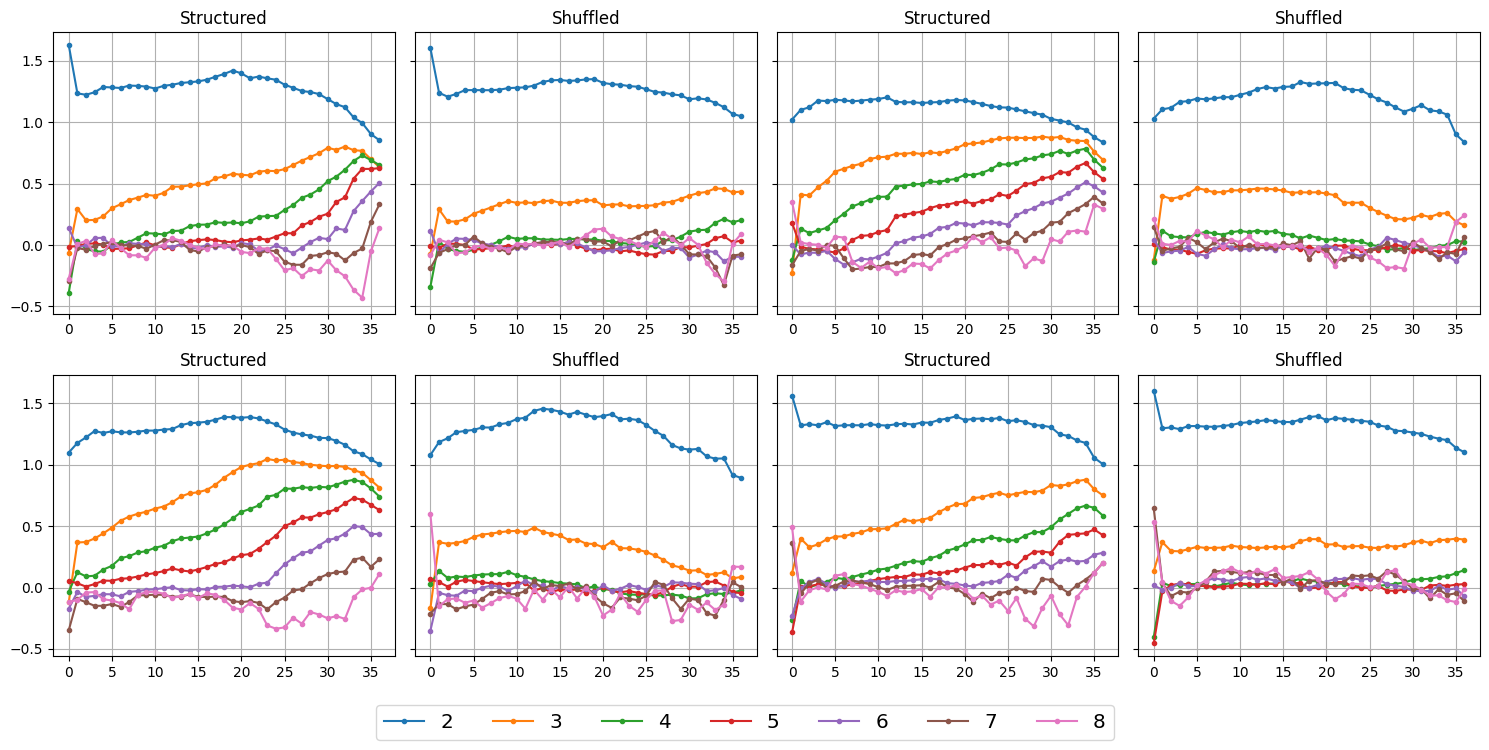

In [56]:
def plot_stats(test_indx, ax, shuffle_indx = 0):
    prompt_indx = filtered_indices[test_indx]
    topic = ds['meta'][prompt_indx]['pile_set_name']
    test_sequence = ds['text'][prompt_indx].strip()
    all_logits, all_probs = get_logits(test_sequence, max_length = max_length, shuffle_indx = shuffle_indx)
    all_cumulants, all_probs_com = calculate_moments(all_logits, all_probs)
    entropy = -torch.sum(all_probs_com * torch.log(all_probs_com + 1e-12), axis = -1).cpu().detach().numpy()
    all_cumulants_np = torch.stack(all_cumulants).cpu().detach().numpy()/np.array([2, 6, 24, 120, 720, 5040, 40320])
    for idx in range(7):
        ax.plot(all_cumulants_np.T[idx], marker = '.', label = idx + 2)
    # plt.plot(np.array(all_entropies).mean(axis = -1), marker = '.', c = 'black', linestyle = '-')
    # ax.axvline(16, c = 'red', linestyle = 'dotted')
    # ax.set_title(f"{prompt_indx}, {topic}")
    shuffled = "Shuffled" if shuffle_indx > 0 else "Structured"
    ax.set_title(shuffled)
    ax.grid(True)
    # ax.legend()

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey = True)
for qq, indx in enumerate(np.random.choice(2244, 4)): 
    # for shuffle_indx in range(5): plot_stats(indx, axes[qq][shuffle_indx], shuffle_indx)
    plot_stats(indx, axes[qq//2][qq%2*2], 0)
    plot_stats(indx, axes[qq//2][qq%2*2 + 1], 4)
handles_psim, labels_psim = axes[0, 0].get_legend_handles_labels()
fig.legend(handles_psim, labels_psim, loc='upper center', bbox_to_anchor=(0.5, -0.0), ncol = 7,  fontsize = "x-large")
plt.tight_layout()
plt.show()

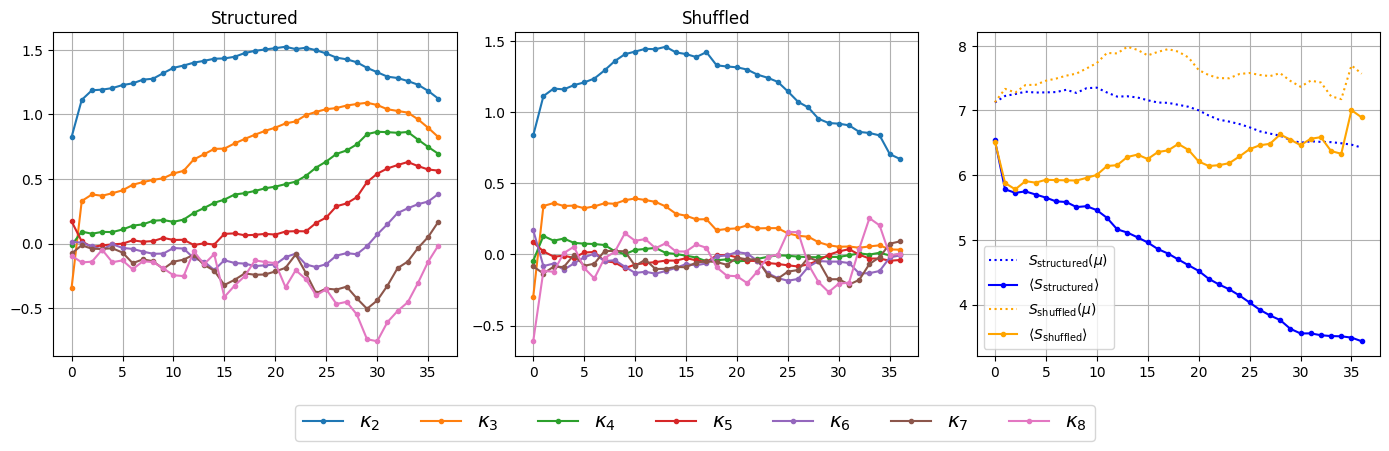

In [98]:
def plot_stats(test_indx, ax, shuffle_indx = 0):
    prompt_indx = filtered_indices[test_indx]
    topic = ds['meta'][prompt_indx]['pile_set_name']
    test_sequence = ds['text'][prompt_indx].strip()
    all_logits, all_probs = get_logits(test_sequence, max_length = max_length, shuffle_indx = shuffle_indx)
    all_cumulants, all_probs_com = calculate_moments(all_logits, all_probs)
    entropy = -torch.sum(all_probs_com * torch.log(all_probs_com + 1e-12), axis = -1).cpu().detach().numpy()
    all_cumulants_np = torch.stack(all_cumulants).cpu().detach().numpy()/np.array([2, 6, 24, 120, 720, 5040, 40320])
    for idx in range(7):
        ax.plot(all_cumulants_np.T[idx], marker='.', label=f'$\kappa_{{{idx + 2}}}$')
    # plt.plot(np.array(all_entropies).mean(axis = -1), marker = '.', c = 'black', linestyle = '-')
    # ax.axvline(16, c = 'red', linestyle = 'dotted')
    # ax.set_title(f"{prompt_indx}, {topic}")
    shuffled = "Shuffled" if shuffle_indx > 0 else "Structured"
    ax.set_title(shuffled)
    ax.grid(True)
    all_entropies= []
    for idx in range(len(all_logits)):
        # print("Hi")
        logits, probs = all_logits[idx], all_probs[idx].cpu().detach().numpy()
        all_entropies.append(-(probs*np.log(probs)).sum(axis = -1).mean())
    return entropy, all_entropies
    # ax.legend()

test_indx = np.random.choice(2244, 1)[0]


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# for qq, test_indx in enumerate(np.random.choice(2244, 1)): 
    # for shuffle_indx in range(5): plot_stats(indx, axes[qq][shuffle_indx], shuffle_indx)
entropy, all_entropies = plot_stats(test_indx, axes[0], 0)
axes[2].plot(entropy, c = 'blue', linestyle = 'dotted',label = "$S_{\\text{structured}}(\mu)$")
axes[2].plot(all_entropies, marker = '.', c = 'blue', label = "$\langle S_{\\text{structured}} \\rangle$")
entropy, all_entropies = plot_stats(test_indx, axes[1], 4)
axes[2].plot(entropy, c = 'orange', linestyle = 'dotted', label = "$S_{\\text{shuffled}}(\mu)$")
axes[2].plot(all_entropies, marker = '.', c = 'orange', label = "$\langle S_{\\text{shuffled}} \\rangle$")
axes[2].grid(True)
axes[2].legend()
handles_psim, labels_psim = axes[0].get_legend_handles_labels()
fig.legend(handles_psim, labels_psim, loc='upper center', bbox_to_anchor=(0.5, -0.0), ncol = 7,  fontsize = "x-large")
plt.tight_layout()
plt.show()

In [79]:
all_entropies[0].shape

()

In [142]:
text = ds['text'][5246].strip()
tokens = tokenizer.encode(text, add_special_tokens=False)
tokenizer.decode(tokens[:max_length])

'Introduction {#Sec1}\n============\n\nCoronary heart disease is one of the leading causes of mortality in the world today (MacKay & Mensah, [@CR27]; Murray & Lopez, [@CR31]), and although new cardiac treatments have helped fight coronary heart disease in recent years, an estimated 1/3 of coronary heart disease risk factors remain elusive (Gudnason, [@CR22]). The addition of psychological factors to standard biomedical risk factors may enhance the prediction of patients at risk. Initial research on the Type A behavior pattern suggested that psychological factors were related to increased risk of heart attacks, but further investigations on Type A behavior were inconclusive (Rozanski et al., [@CR44]). Subsequently, researchers turned their focus towards isolated factors such as hostility, depression, anxiety, social isolation, and chronic stress (Matthews, [@CR29]; Rozanski et al., [@CR44], [@CR43]; Strike & Steptoe, [@CR51]) to document a relationship between psychological factors and 

## Mean energy difference

In [44]:
from scipy.stats import norm
from scipy.special import hermite

def reconstruct_histogram(cumulants, x_range, num_points=1000):
    """
    Reconstruct a histogram from the first 5 cumulants using Edgeworth expansion.
    
    Parameters:
        cumulants (list): List of the first 5 cumulants [k1, k2, k3, k4, k5].
        x_range (tuple): Range of x values (xmin, xmax).
        num_points (int): Number of points for the histogram.
    
    Returns:
        x_vals (numpy.ndarray): X values of the histogram.
        pdf (numpy.ndarray): Reconstructed probability density function.
    """
    k2, k3, k4, k5 = cumulants[:4]
    
    # Convert cumulants to moments
    m1 = 0  # Mean
    m2 = k2  # Variance
    m3 = k3  # Skewness-related moment
    m4 = k4  # Kurtosis-related moment
    m5 = k5  # Higher-order moment
    
    # Normalize higher-order moments using variance
    sigma = np.sqrt(m2)
    gamma1 = m3 / sigma**3  # Skewness
    gamma2 = m4 / sigma**4  # Excess kurtosis
    gamma3 = m5 / sigma**5  # Fifth cumulant normalized
    
    # Standard normal distribution
    x_vals = np.linspace(x_range[0], x_range[1], num_points)
    z = (x_vals - m1) / sigma
    pdf = norm.pdf(z) / sigma  # Start with Gaussian approximation
    
    # Edgeworth expansion terms
    term3 = (gamma1 / 6) * (z**3 - 3 * z) * norm.pdf(z)
    term4 = (gamma2 / 24) * (z**4 - 6 * z**2 + 3) * norm.pdf(z)
    term5 = (gamma3 / 120) * (z**5 - 10 * z**3 + 15 * z) * norm.pdf(z)
    
    # Add corrections to the Gaussian
    pdf += term3 + term4 + term5
    pdf = np.clip(pdf, 0, None)  # Ensure non-negative probabilities
    
    return x_vals, pdf


test_indx = 45
prompt_indx = filtered_indices[test_indx]
topic = ds['meta'][prompt_indx]['pile_set_name']
test_sequence = ds['text'][prompt_indx].strip()
all_logits, all_probs = get_logits(test_sequence, max_length = max_length, shuffle_indx = 0)
all_cumulants, all_probs_com = calculate_moments(all_logits, all_probs)


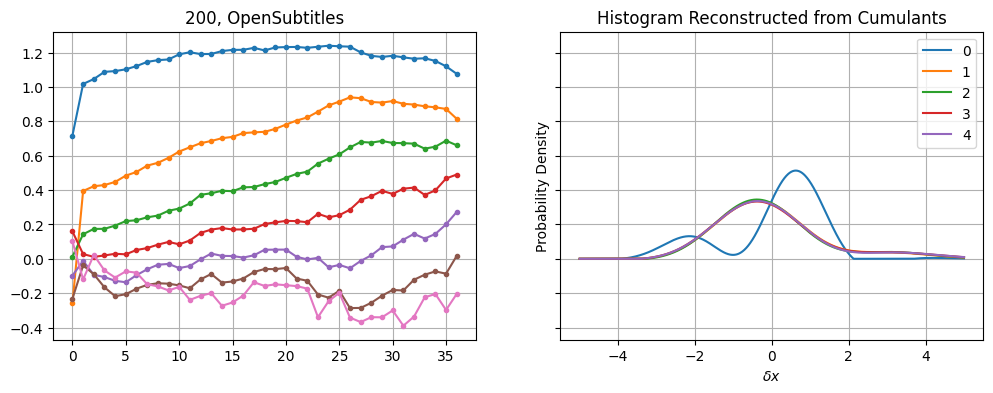

In [54]:
fig, axes = plt.subplots(1,2, figsize=(12, 4), sharey = True)

plot_stats(test_indx, axes[0], shuffle_indx = 0)
ax = axes[1]
for lnum in range(0, 5, 1):
    x_vals, pdf = reconstruct_histogram(all_cumulants[lnum].cpu().detach().numpy(), x_range= (-5, 5))
    # Plot the reconstructed histogram
    
    ax.plot(x_vals, pdf, label=lnum)
ax.set_title("Histogram Reconstructed from Cumulants")
ax.set_xlabel("$\delta x$")
ax.set_ylabel("Probability Density")
ax.legend()
ax.grid()
plt.show()

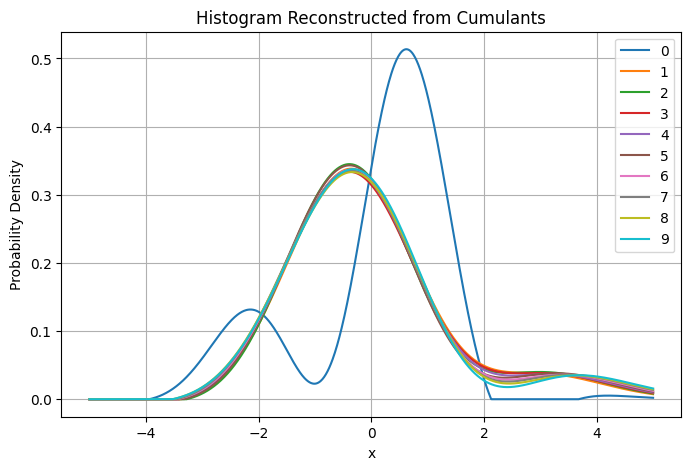

In [47]:
plt.figure(figsize=(8, 5))
for lnum in range(0, 10, 1):
    x_vals, pdf = reconstruct_histogram(all_cumulants[lnum].cpu().detach().numpy(), x_range= (-5, 5))
    # Plot the reconstructed histogram
    plt.plot(x_vals, pdf, label=lnum)
plt.title("Histogram Reconstructed from Cumulants")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid()
plt.show()

## Rough

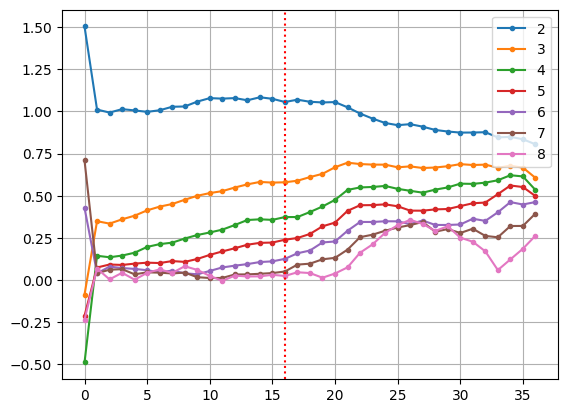

In [114]:
# all_cumulants_np = torch.stack(all_cumulants).cpu().detach().numpy()/np.array([2, 6, 24, 120, 720, 5040, 5040*8])
# plt.plot(entropy, marker = '.', label = 0, c = 'black')
for idx in range(7):
    plt.plot(all_cumulants_np.T[idx], marker = '.', label = idx + 2)
# plt.plot(np.array(all_entropies).mean(axis = -1), marker = '.', c = 'black', linestyle = '-')
plt.axvline(16, c = 'red', linestyle = 'dotted')
plt.grid(True)
plt.legend()
plt.show()

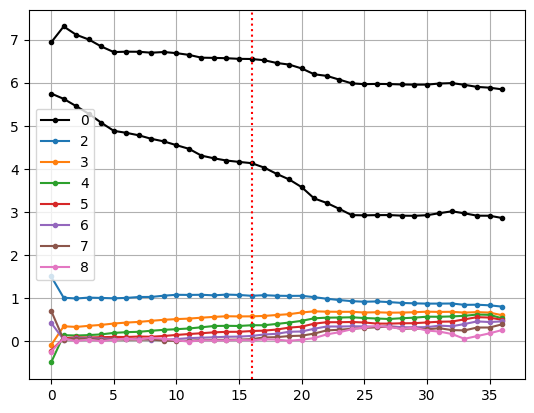

In [78]:
# all_cumulants_np = torch.stack(all_cumulants).cpu().detach().numpy()/np.array([2, 6, 24, 120, 720, 5040, 5040*8])
plt.plot(entropy, marker = '.', label = 0, c = 'black')
for idx in range(7):
    plt.plot(all_cumulants_np.T[idx], marker = '.', label = idx + 2)
plt.plot(np.array(all_entropies).mean(axis = -1), marker = '.', c = 'black', linestyle = '-')
plt.axvline(16, c = 'red', linestyle = 'dotted')
plt.grid(True)
plt.legend()
plt.show()